In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
from IPython import display
import matplotlib.pyplot as plt

In [2]:
def as_gif(images, path="temp.gif", dur=4):
  # Render the images as the gif (15Hz control frequency):
  images[0].save(path, save_all=True, append_images=images[1:], duration=int(1000/dur), loop=0)
  gif_bytes = open(path,"rb").read()
  return gif_bytes

In [3]:
builder = tfds.builder_from_directory("data/fmb/0.1.0")

In [4]:
ds = builder.as_dataset(split="train")

In [6]:
iterator = iter(ds)

In [7]:
episode = next(iterator)

In [8]:
print(episode.keys())

dict_keys(['episode_metadata', 'steps'])


In [10]:
episode['episode_metadata'].keys()

dict_keys(['episode_language_embedding', 'episode_language_instruction', 'episode_task', 'file_path'])

In [11]:
episode['episode_metadata']['episode_task']

<tf.Tensor: shape=(), dtype=string, numpy=b'multi_object_manipulation/board_2'>

In [12]:
episodes = list(episode['steps'])

In [13]:
print(f"Length of the episode: {len(episodes)}")

Length of the episode: 111


In [14]:
episodes[0].keys()

dict_keys(['action', 'discount', 'is_first', 'is_last', 'is_terminal', 'language_embedding', 'language_instruction', 'observation', 'reward'])

In [15]:
episodes[60]['language_instruction']

<tf.Tensor: shape=(), dtype=string, numpy=b'Move to above the board.'>

In [17]:
episodes[60]['observation'].keys()

dict_keys(['color_id', 'eef_force', 'eef_pose', 'eef_torque', 'eef_vel', 'image_side_1', 'image_side_1_depth', 'image_side_2', 'image_side_2_depth', 'image_wrist_1', 'image_wrist_1_depth', 'image_wrist_2', 'image_wrist_2_depth', 'joint_pos', 'joint_vel', 'length', 'object_id', 'primitive', 'shape_id', 'size', 'state_gripper_pose'])

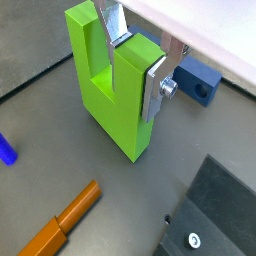

In [34]:
Image.fromarray(episodes[50]['observation']['image_wrist_1'].numpy())

In [19]:
episode['episode_metadata']['episode_language_instruction']

<tf.Tensor: shape=(), dtype=string, numpy=b'Pick up the green object and insert it.'>

In [35]:
images = []
for i, step in enumerate(episode["steps"]):
    if i % 10 == 0:

        images.append(
            Image.fromarray(
            np.concatenate((
                    step["observation"]["image_side_1"].numpy(),
                    step["observation"]["image_side_2"].numpy(),
                    step["observation"]["image_wrist_1"].numpy(),
                    step["observation"]["image_wrist_2"].numpy()
            ), axis=1)
            )
        )

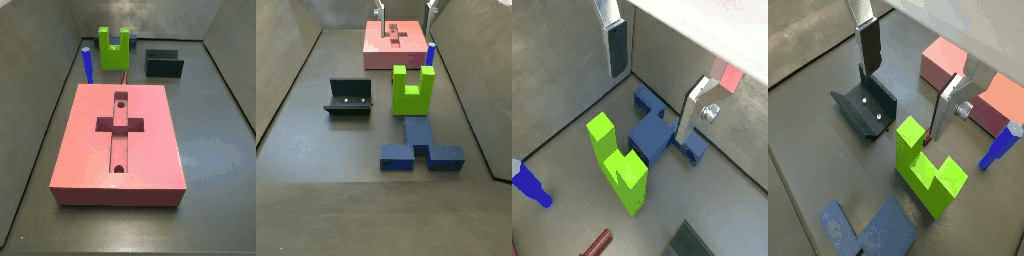

In [36]:
display.Image(as_gif(images, dur=3))

In [44]:
episodes[10]['action'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 0.18571429, -0.02857143, -0.33714285], dtype=float32)>

In [38]:
episodes[10]['observation']['eef_pose'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.5056412 , 0.08232286, 0.1463157 ], dtype=float32)>

In [ ]:
episodes[10]['observation']['eef_vel'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([-0.00821972, -0.0124155 , -0.06418362], dtype=float32)>

In [40]:
episodes[10]['observation']['eef_force'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.80390483, 3.242409  , 4.5041327 ], dtype=float32)>

In [57]:
episodes[11]['action'][:3] * 1/10

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 0.016     ,  0.        , -0.03285714], dtype=float32)>

In [56]:
episodes[12]['observation']['eef_pose'][:3] - episodes[11]['observation']['eef_pose'][:3]

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 1.2891889e-03, -6.7099929e-05, -2.9322654e-03], dtype=float32)>

In [34]:
from scipy.spatial.transform import Rotation as R

In [36]:
pose7d = episodes[10]['observation']['eef_pose'].numpy()

In [37]:
x, y, z, qx, qy, qz, qw = pose7d

In [38]:
r = R.from_quat([qx, qy, qz, qw])

In [39]:
roll, pitch, yaw = r.as_euler('xyz', degrees = False)

In [40]:
pose6d = [x, y, z, roll, pitch, yaw]

In [41]:
print(pose6d)

[0.5056412, 0.08232286, 0.1463157, -3.123613099193759, -0.026394696088226643, 1.5254499619067228]


In [59]:
steps = episodes

In [61]:
tcp = np.stack([s["observation"]["eef_pose"].numpy() for s in steps])
actions = np.stack([s["action"].numpy() for s in steps])

pos = tcp[:, :3]
state_delta = pos[1:] - pos[:-1]
action_xyz = actions[:-1, :3]

print("RMSE action xyz vs next pos:", np.sqrt(np.mean((action_xyz - pos[1:]) ** 2)))
print("RMSE action xyz vs curr pos:", np.sqrt(np.mean((action_xyz - pos[:-1]) ** 2)))
print("RMSE action xyz vs pos delta:", np.sqrt(np.mean((action_xyz - state_delta) ** 2)))

RMSE action xyz vs next pos: 0.4871374
RMSE action xyz vs curr pos: 0.4916948
RMSE action xyz vs pos delta: 0.3673108


In [81]:
print("pos range:", pos.min(axis=0), pos.max(axis=0))
print("delta range:", state_delta.min(axis=0), state_delta.max(axis=0))
print("action xyz range:", action_xyz.min(axis=0), action_xyz.max(axis=0))
print("action xyz mean/std:", action_xyz.mean(axis=0), action_xyz.std(axis=0))

pos range: [ 0.49481308 -0.210763    0.09008543] [0.54618275 0.09979067 0.3278375 ]
delta range: [-0.00534892 -0.03488079 -0.01377043] [0.00708723 0.00390761 0.04334079]
action xyz range: [-0.23428571 -1.4        -0.7714286 ] [0.6257143  0.05348181 1.4       ]
action xyz mean/std: [ 0.02679489 -0.15283711 -0.09197573] [0.16900638 0.3870983  0.455241  ]


In [82]:
for i in range(3):
    a = action_xyz[:, i]
    d = state_delta[:, i]
    scale = np.dot(a, d) / (np.dot(a, a) + 1e-8)
    pred = scale * a
    rmse = np.sqrt(np.mean((pred - d) ** 2))
    corr = np.corrcoef(a, d)[0, 1]
    print(i, "scale:", scale, "scaled_rmse:", rmse, "corr:", corr)

0 scale: 0.009504530214234648 scaled_rmse: 0.0016986192 corr: 0.6909518197522874
1 scale: 0.01788931870733633 scaled_rmse: 0.0034975142 corr: 0.8918140270559779
2 scale: 0.015834852166239116 scaled_rmse: 0.0044677085 corr: 0.8555870474504682


In [90]:
import numpy as np

steps = list(episode["steps"])

eef_pose = np.stack([
    s["observation"]["eef_pose"].numpy()
    for s in steps
])  # [T, 7], XYZ + quat

eef_vel = np.stack([
    s["observation"]["eef_vel"].numpy()
    for s in steps
])  # [T, 6], XYZ + RPY velocity/twist

actions = np.stack([
    s["action"].numpy()
    for s in steps
])  # [T, 7]

action_twist = actions[:, :6]

print("eef_pose shape:", eef_pose.shape)
print("eef_vel shape:", eef_vel.shape)
print("actions shape:", actions.shape)

print("\nEEF vel range:")
print(eef_vel.min(axis=0))
print(eef_vel.max(axis=0))
print("EEF vel mean/std:")
print(eef_vel.mean(axis=0), eef_vel.std(axis=0))

print("\nAction twist range:")
print(action_twist.min(axis=0))
print(action_twist.max(axis=0))
print("Action twist mean/std:")
print(action_twist.mean(axis=0), action_twist.std(axis=0))

eef_pose shape: (111, 7)
eef_vel shape: (111, 6)
actions shape: (111, 7)

EEF vel range:
[-0.04913895 -0.30712304 -0.12446383 -0.12010825 -0.17038395 -0.1459397 ]
[0.05927382 0.03001356 0.31307852 0.11138711 0.10385782 0.15371701]
EEF vel mean/std:
[ 0.00167077 -0.02348834 -0.00910598 -0.00016794 -0.00852563 -0.00239198] [0.0219195  0.06381138 0.07109888 0.03455434 0.05198912 0.04945654]

Action twist range:
[-0.23428571 -1.4        -0.7714286  -0.15285714 -0.20571429 -0.26      ]
[0.6257143  0.05348181 1.4        0.27142859 0.158863   0.26      ]
Action twist mean/std:
[ 0.02655349 -0.1514602  -0.09114711 -0.00442717 -0.01680103  0.00612932] [0.16826244 0.38562107 0.45326906 0.07567294 0.07105796 0.07616734]


In [91]:
for i in range(6):
    a = action_twist[:, i]
    v = eef_vel[:, i]

    corr = np.corrcoef(a, v)[0, 1]

    scale = np.dot(a, v) / (np.dot(a, a) + 1e-8)
    pred = scale * a
    rmse_scaled = np.sqrt(np.mean((pred - v) ** 2))

    rmse_raw = np.sqrt(np.mean((a - v) ** 2))

    print(
        i,
        "corr(action, eef_vel):", corr,
        "scale:", scale,
        "raw_rmse:", rmse_raw,
        "scaled_rmse:", rmse_scaled,
    )

0 corr(action, eef_vel): 0.6084242165627519 scale: 0.07886223582866254 raw_rmse: 0.1578729 scaled_rmse: 0.017400853
1 corr(action, eef_vel): 0.8703806380910788 scale: 0.14550489631945757 raw_rmse: 0.35541156 scaled_rmse: 0.03145802
2 corr(action, eef_vel): 0.8382366972967281 scale: 0.13025677954337803 raw_rmse: 0.40399387 scaled_rmse: 0.038873244
3 corr(action, eef_vel): 0.06356838556137642 scale: 0.02905745458452331 raw_rmse: 0.081277885 scaled_rmse: 0.034484476
4 corr(action, eef_vel): 0.17810164020641778 scale: 0.1502744942384405 raw_rmse: 0.08065162 scaled_rmse: 0.05152821
5 corr(action, eef_vel): 0.7160006840505855 scale: 0.45940732388721583 raw_rmse: 0.05408988 scaled_rmse: 0.034918673


In [92]:
pose_xyz = eef_pose[:, :3]
action_xyz = actions[:, :3]

rmse_to_pose = np.sqrt(np.mean((action_xyz - pose_xyz) ** 2))
print("RMSE action_xyz vs absolute pose_xyz:", rmse_to_pose)

RMSE action_xyz vs absolute pose_xyz: 0.49046358


In [52]:
gripper_action = actions[:, 6]
gripper_state = np.stack([
    np.asarray(s["observation"]["state_gripper_pose"].numpy()).reshape(())
    for s in steps
])

print("gripper action unique-ish:", np.unique(np.round(gripper_action, 3))[:50])
print("gripper state range:", gripper_state.min(), gripper_state.max())
print("first 30 gripper action:", gripper_action[:30])
print("first 30 gripper state:", gripper_state[:30])

gripper action unique-ish: [0. 1.]
gripper state range: 0.0 1.0
first 30 gripper action: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
first 30 gripper state: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [99]:
all_actions = []
all_vels = []

for episode in ds.take(1):
    steps = list(episode["steps"])

    actions = np.stack([s["action"].numpy() for s in steps])[:, :6]
    eef_vel = np.stack([s["observation"]["eef_vel"].numpy() for s in steps])

    all_actions.append(actions)
    all_vels.append(eef_vel)

A = np.concatenate(all_actions, axis=0)
V = np.concatenate(all_vels, axis=0)

scales = []
for i in range(6):
    a = A[:, i]
    v = V[:, i]

    # zero-intercept least-squares scale: v ~= scale * a
    scale = np.dot(a, v) / (np.dot(a, a) + 1e-8)
    corr = np.corrcoef(a, v)[0, 1]

    scales.append(scale)
    print(i, "scale action->vel:", scale, "corr:", corr)

scales = np.array(scales)
delta_scales = scales / 10.0  # 10 Hz
print("action -> delta scale:", delta_scales)

0 scale action->vel: 0.07886223582866254 corr: 0.6084242165627519
1 scale action->vel: 0.14550489631945757 corr: 0.8703806380910788
2 scale action->vel: 0.13025677954337803 corr: 0.8382366972967281
3 scale action->vel: 0.02905745458452331 corr: 0.06356838556137642
4 scale action->vel: 0.1502744942384405 corr: 0.17810164020641778
5 scale action->vel: 0.45940732388721583 corr: 0.7160006840505855
action -> delta scale: [0.00788622 0.01455049 0.01302568 0.00290575 0.01502745 0.04594073]
